# Oval-like Billiard Trajectories and Phase Space Generation

Processing eccentricity: 0.5
Processing alpha grid point 1/21
Processing alpha grid point 2/21
Processing alpha grid point 3/21
Processing alpha grid point 4/21
Processing alpha grid point 5/21
Processing alpha grid point 6/21
Processing alpha grid point 7/21
Processing alpha grid point 8/21
Processing alpha grid point 9/21
Processing alpha grid point 10/21
Processing alpha grid point 11/21
Processing alpha grid point 12/21
Processing alpha grid point 13/21
Processing alpha grid point 14/21
Processing alpha grid point 15/21
Processing alpha grid point 16/21
Processing alpha grid point 17/21
Processing alpha grid point 18/21
Processing alpha grid point 19/21
Processing alpha grid point 20/21
Processing alpha grid point 21/21


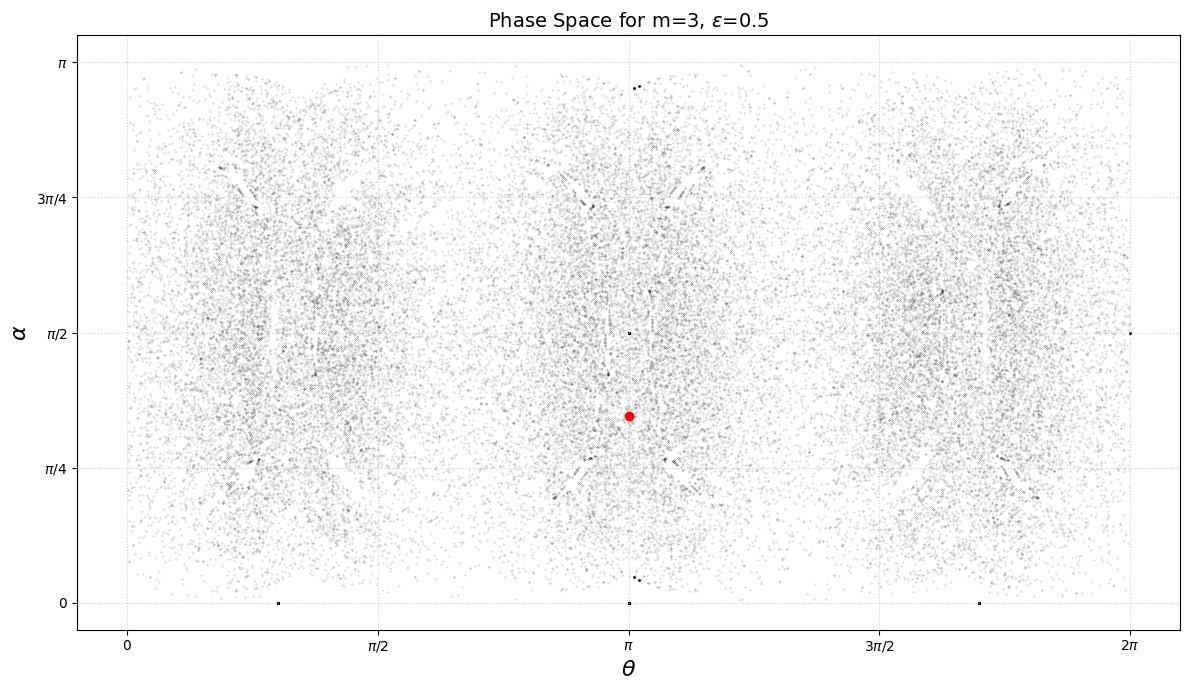

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from billiard_engine import BilliardsNonTimeDependent

theta_0, alpha_0 = np.pi + 0.002, np.pi / 3.0

# If you want to set a single eccentricity (epsilon value), do this:
eccentricities = [0.5]

steps = len(eccentricities)
ics = np.empty(steps, dtype=object)
ics[:] = [(theta_0, alpha_0)] * steps
ics[0] = (theta_0, alpha_0 + 0.04)

# If you want to generate all 32 eccentricities, do this:
# eccentricities = np.linspace(0.001, 0.5, num=32)

i = 0
for ecc in eccentricities:
    print(f"Processing eccentricity: {ecc}")
    sim = BilliardsNonTimeDependent(r0=1.0, eccentricity=ecc, mode=3)
    
    # Running a slightly denser grid for a better visual
    phase_space_df, _ = sim.simulate(
        alpha_min=0.0,
        alpha_max=np.pi,
        theta_min=0.0,
        theta_max=2*np.pi,
        num_alpha=20,
        num_theta=20,
        iterations_per_trajectory=100
    )
    
    # Setup the plot
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.scatter(phase_space_df["theta"], phase_space_df["alpha"], s=0.05, color='black', alpha=0.4)
    
    # Label Theta Axis (0 to 2pi)
    theta_ticks = [0, 0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
    theta_labels = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
    ax.set_xticks(theta_ticks)
    ax.set_xticklabels(theta_labels)
    
    # Label Alpha Axis (0 to pi)
    alpha_ticks = [0, 0.25*np.pi, 0.5*np.pi, 0.75*np.pi, np.pi]
    alpha_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
    ax.set_yticks(alpha_ticks)
    ax.set_yticklabels(alpha_labels)
    
    # Styling
    ax.set_title(f"Phase Space for m={sim.m}, $\epsilon$={sim.eccentricity}", fontsize=14)
    ax.set_xlabel(r"$\theta$", fontsize=16)
    ax.set_ylabel(r"$\alpha$", fontsize=16)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.plot(ics[i][0], ics[i][1], marker='o', color='red')
    
    plt.tight_layout()
    plt.show()

    i = i + 1